In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Generate synthetic dataset
np.random.seed(42)
n = 800

study_hours = np.random.uniform(0, 20, n)
attendance = np.random.uniform(50, 100, n)
practice = np.random.uniform(0, 100, n)
sleep = np.random.uniform(4, 10, n)
gpa = np.random.uniform(2.0, 4.0, n)

# Create label with some logic + randomness
score = (0.3*study_hours +
         0.01*attendance +
         0.02*practice +
         0.2*sleep +
         2*gpa +
         np.random.normal(0, 2, n))

pass_label = (score > 15).astype(int)

X = np.column_stack((study_hours, attendance, practice, sleep, gpa))
y = pass_label

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model = Sequential()
model.add(Dense(16, activation='relu', input_dim=5))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=Adam(0.001),
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50, batch_size=16)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8382 - loss: 0.5213
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8417 - loss: 0.4411
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8555 - loss: 0.3716
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8681 - loss: 0.3262
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8664 - loss: 0.2937
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8480 - loss: 0.3155
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8635 - loss: 0.3021
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8742 - loss: 0.2795
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8855 - loss: 0.2714
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8784 - loss: 0.2690
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8764 - loss: 0.2949
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8821 - 

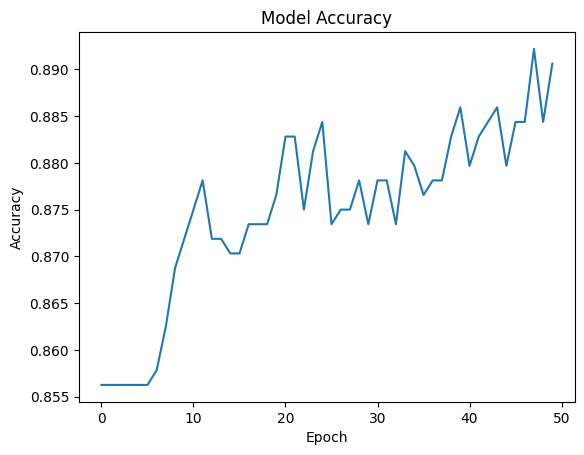

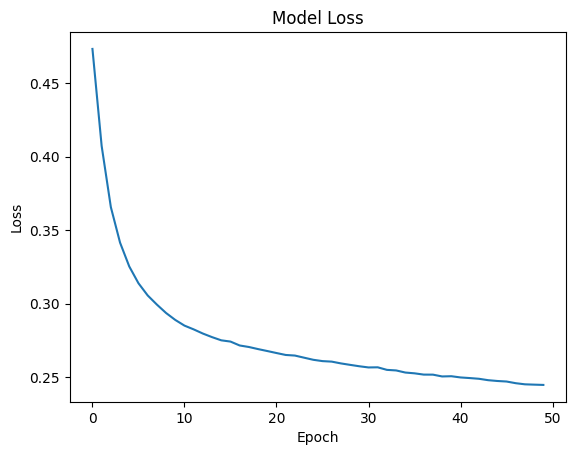

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(model.history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Plot loss
plt.plot(model.history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


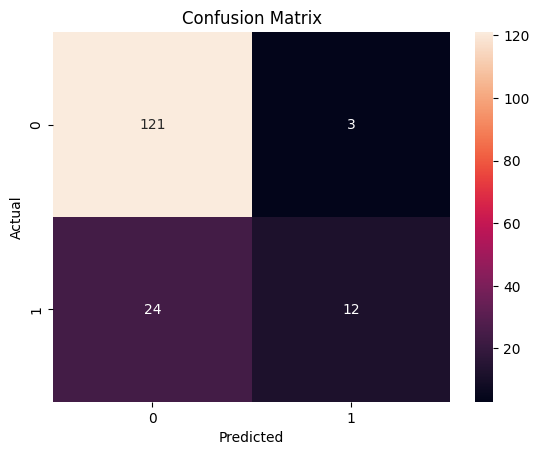

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()